In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis
from scipy.fft import fft
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.model_selection import GridSearchCV, cross_val_score

print('All libraries imported successfully')
!wget https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip
!unzip "UCI HAR Dataset.zip"

All libraries imported successfully


'wget' is not recognized as an internal or external command,
operable program or batch file.
'unzip' is not recognized as an internal or external command,
operable program or batch file.


### Cell 1 — Load dataset

In [13]:
def load_data():
    print('Loading UCI HAR Dataset...')
    
    data_folder = r'C:\Users\workstation\OneDrive\Afbeeldingen\library py\fri_practice\UCI HAR Dataset\\'

    features = pd.read_csv(
        data_folder + 'features.txt',
        sep='\s+',
        header=None,
        names=['id', 'name']
    )

    columnNames = features['name'].values

    labelsMap = pd.read_csv(
        data_folder + 'activity_labels.txt',
        sep='\s+',
        header=None,
        names=['id', 'activity_name']
    )

    def read_set(set_name):

        X = pd.read_csv(
            f'{data_folder}{set_name}/X_{set_name}.txt',
            sep='\s+',
            header=None
        )

        X.columns = columnNames

        y = pd.read_csv(
            f'{data_folder}{set_name}/y_{set_name}.txt',
            sep='\s+',
            header=None,
            names=['Activity_ID']
        )

        y['Activity_Name'] = y['Activity_ID'].map(
            labelsMap.set_index('id')['activity_name']
        )

        subject = pd.read_csv(
            f'{data_folder}{set_name}/subject_{set_name}.txt',
            sep='\s+',
            header=None,
            names=['Subject_ID']
        )

        return pd.concat([subject, y, X], axis=1)

    train_df = read_set('train')
    test_df = read_set('test')

    print(f'Train shape : {train_df.shape}')
    print(f'Test  shape : {test_df.shape}')

    return train_df, test_df


train_data, test_data = load_data()

train_data.head(3)

Loading UCI HAR Dataset...
Train shape : (7352, 564)
Test  shape : (2947, 564)


,Subject_ID,Activity_ID,Activity_Name,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,...,fBodyBodyGyroJerkMag-meanFreq(),fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)"
0,1,5,STANDING,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,...,-0.074323,-0.298676,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627
1,1,5,STANDING,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,...,0.158075,-0.595051,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317
2,1,5,STANDING,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,...,0.414503,-0.390748,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118


### Cell 2 — Load raw inertial signals

In [14]:
def load_inertial_signals(set_name):
    print(f'Loading raw signals for {set_name}...')

    data_folder = rf'C:\Users\workstation\OneDrive\Afbeeldingen\library py\fri_practice\UCI HAR Dataset\{set_name}\Inertial Signals\\'

    filenames = [
        'body_acc_x_','body_acc_y_','body_acc_z_',
        'body_gyro_x_','body_gyro_y_','body_gyro_z_',
        'total_acc_x_','total_acc_y_','total_acc_z_'
    ]

    signals = []

    for name in filenames:
        data = pd.read_csv(
            f'{data_folder}{name}{set_name}.txt',
            sep='\s+',
            header=None
        )

        signals.append(data.values)

    return np.transpose(np.array(signals), (1, 2, 0))


X_train_raw = load_inertial_signals('train')
X_test_raw  = load_inertial_signals('test')

print(f'X_train_raw shape : {X_train_raw.shape}')
print(f'X_test_raw  shape : {X_test_raw.shape}')

Loading raw signals for train...
Loading raw signals for test...
X_train_raw shape : (7352, 128, 9)
X_test_raw  shape : (2947, 128, 9)


### Cell 3 — Data quality checks

In [15]:
print('=== Data Quality Report ===')
print(f'NaN in train     : {train_data.isnull().sum().sum()}')
print(f'NaN in test      : {test_data.isnull().sum().sum()}')
print(f'Duplicate rows   : {train_data.duplicated().sum()}')
print()
print('=== Train / Test Split ===')
total = train_data.shape[0] + test_data.shape[0]
print(f'Train : {train_data.shape[0]} samples ({train_data.shape[0]/total:.0%})')
print(f'Test  : {test_data.shape[0]} samples ({test_data.shape[0]/total:.0%})')
print()
print('=== Class Distribution (train) ===')
print(train_data['Activity_Name'].value_counts())

=== Data Quality Report ===
NaN in train     : 0
NaN in test      : 0
Duplicate rows   : 0

=== Train / Test Split ===
Train : 7352 samples (71%)
Test  : 2947 samples (29%)

=== Class Distribution (train) ===
Activity_Name
LAYING                1407
STANDING              1374
SITTING               1286
WALKING               1226
WALKING_UPSTAIRS      1073
WALKING_DOWNSTAIRS     986
Name: count, dtype: int64


### Cell 4 — Activity class balance

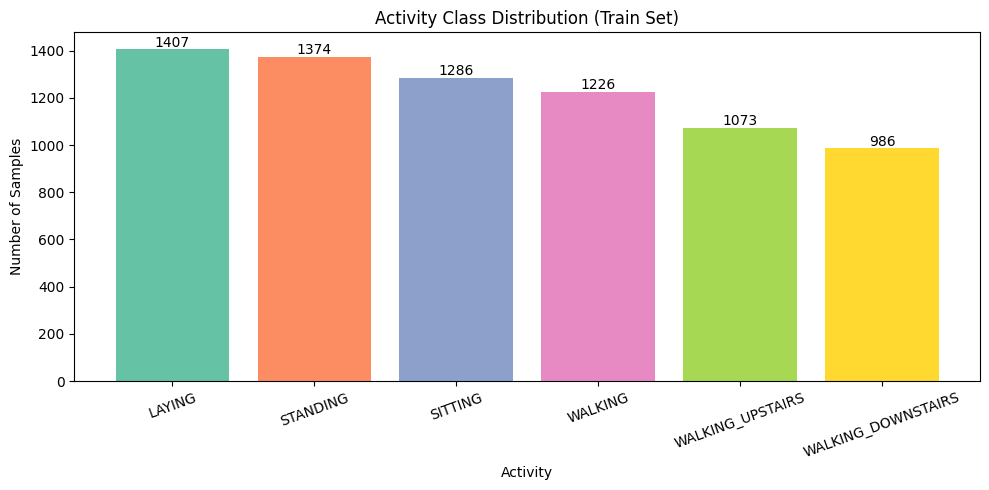

Insight: Classes are roughly balanced — no major imbalance issue.


In [16]:
plt.figure(figsize=(10, 5))
counts = train_data['Activity_Name'].value_counts()
bars = plt.bar(counts.index, counts.values, color=sns.color_palette('Set2', len(counts)))
plt.title('Activity Class Distribution (Train Set)')
plt.xlabel('Activity')
plt.ylabel('Number of Samples')
plt.xticks(rotation=20)
for bar, val in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10, str(val), ha='center', fontsize=10)
plt.tight_layout()
plt.show()
print('Insight: Classes are roughly balanced — no major imbalance issue.')

### Cell 5 — Sensor signal plots per activity

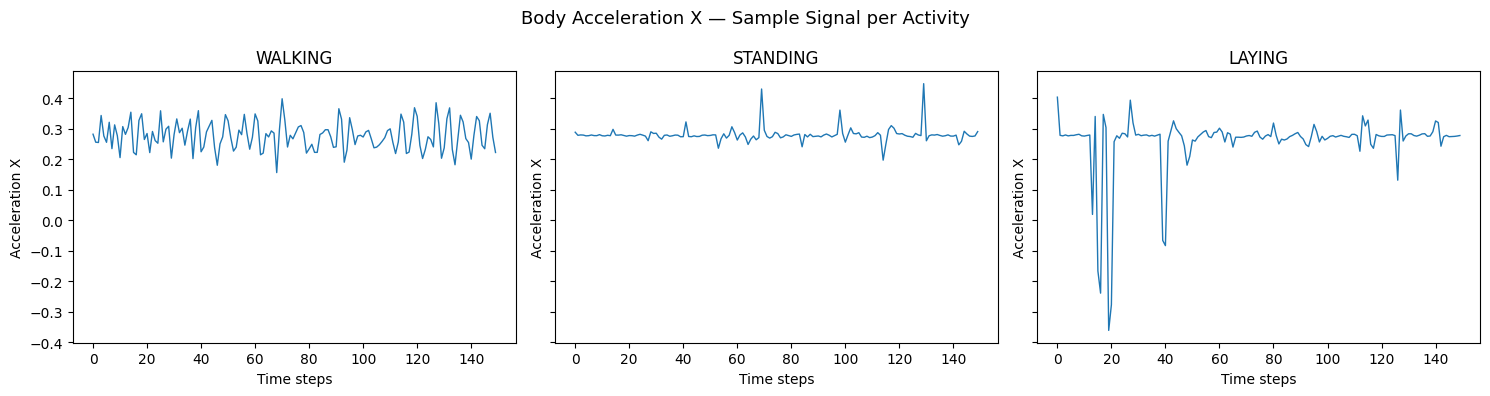

Insight: WALKING has clear periodic oscillations. STANDING and LAYING are near-flat.


In [17]:
activities  = ['WALKING', 'STANDING', 'LAYING']
signal_col  = 'tBodyAcc-mean()-X'
fig, axes   = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, activity in zip(axes, activities):
    subset = train_data[train_data['Activity_Name'] == activity][signal_col].values[:150]
    ax.plot(subset, linewidth=1)
    ax.set_title(f'{activity}')
    ax.set_xlabel('Time steps')
    ax.set_ylabel('Acceleration X')

plt.suptitle('Body Acceleration X — Sample Signal per Activity', fontsize=13)
plt.tight_layout()
plt.show()
print('Insight: WALKING has clear periodic oscillations. STANDING and LAYING are near-flat.')

### Cell 6 — Correlation matrix (first 20 features)

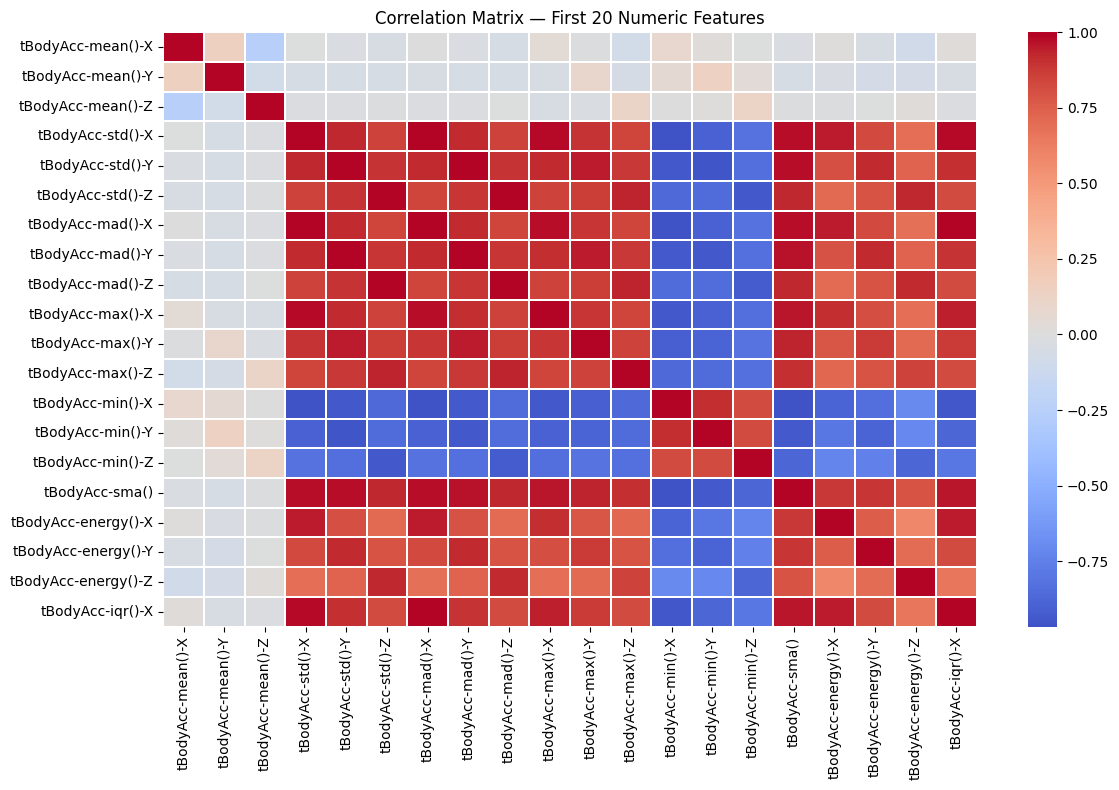

Insight: High correlation between some body acceleration features — expected for XYZ axes.


In [18]:
numeric_data = train_data.select_dtypes(include=['number'])
corr = numeric_data.iloc[:, 2:22].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, cmap='coolwarm', center=0, linewidths=0.3, annot=False)
plt.title('Correlation Matrix — First 20 Numeric Features')
plt.tight_layout()
plt.show()
print('Insight: High correlation between some body acceleration features — expected for XYZ axes.')

### Cell 7 — Distribution plots

C:\Users\workstation\AppData\Local\Temp\ipykernel_22328\1652785480.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Activity_Name', y=feature, data=train_data, ax=axes[1], palette='Set2')


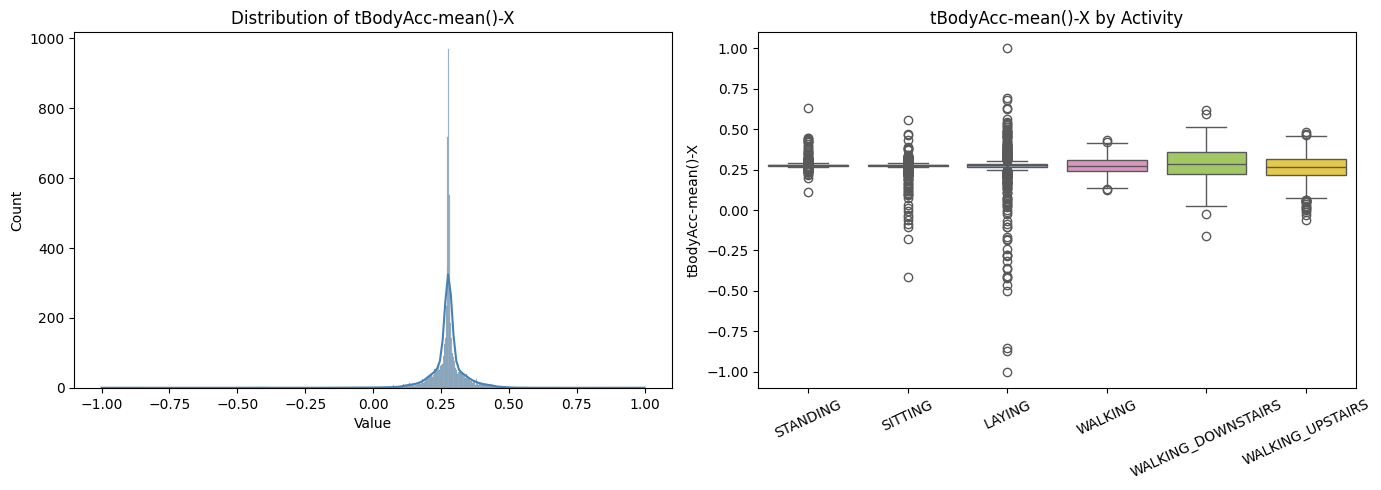

Insight: Body acceleration X clearly separates walking activities from static ones.


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(numeric_data.iloc[:, 2], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title(f'Distribution of {numeric_data.columns[2]}')
axes[0].set_xlabel('Value')


feature = 'tBodyAcc-mean()-X'
sns.boxplot(x='Activity_Name', y=feature, data=train_data, ax=axes[1], palette='Set2')
axes[1].set_title(f'{feature} by Activity')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.show()
print('Insight: Body acceleration X clearly separates walking activities from static ones.')

### Cell 8 — Signal names

In [20]:
SIGNAL_NAMES = [
    'body_acc_x','body_acc_y','body_acc_z',
    'body_gyro_x','body_gyro_y','body_gyro_z',
    'total_acc_x','total_acc_y','total_acc_z'
]
print(f'Number of signals : {len(SIGNAL_NAMES)}')
print(f'Signal names      : {SIGNAL_NAMES}')

Number of signals : 9
Signal names      : ['body_acc_x', 'body_acc_y', 'body_acc_z', 'body_gyro_x', 'body_gyro_y', 'body_gyro_z', 'total_acc_x', 'total_acc_y', 'total_acc_z']


### Cell 9 — Time-domain features (mean, std, min, max, median, skew, kurtosis)

In [21]:
def extract_time_domain_features(raw_data):
    print('Extracting time-domain features...')
    records = []
    for sample in raw_data:
        row = {}
        for i, sig_name in enumerate(SIGNAL_NAMES):
            signal = sample[:, i]
            row[f'{sig_name}_mean']     = np.mean(signal)
            row[f'{sig_name}_std']      = np.std(signal)
            row[f'{sig_name}_min']      = np.min(signal)
            row[f'{sig_name}_max']      = np.max(signal)
            row[f'{sig_name}_median']   = np.median(signal)
            row[f'{sig_name}_skew']     = skew(signal)
            row[f'{sig_name}_kurtosis'] = kurtosis(signal)
        records.append(row)
    df = pd.DataFrame(records)
    print(f'  Output shape : {df.shape}  (9 signals x 7 stats = 63 features)')
    return df

X_train_time = extract_time_domain_features(X_train_raw)
X_test_time  = extract_time_domain_features(X_test_raw)
X_train_time.head(3)

Extracting time-domain features...
  Output shape : (7352, 63)  (9 signals x 7 stats = 63 features)
Extracting time-domain features...
  Output shape : (2947, 63)  (9 signals x 7 stats = 63 features)


,body_acc_x_mean,body_acc_x_std,body_acc_x_min,body_acc_x_max,body_acc_x_median,body_acc_x_skew,body_acc_x_kurtosis,body_acc_y_mean,body_acc_y_std,body_acc_y_min,...,total_acc_y_median,total_acc_y_skew,total_acc_y_kurtosis,total_acc_z_mean,total_acc_z_std,total_acc_z_min,total_acc_z_max,total_acc_z_median,total_acc_z_skew,total_acc_z_kurtosis
0,0.002269,0.002941,-0.004294,0.010810,0.002025,0.481111,-0.395797,-0.001655,0.004601,-0.012610,...,-0.124302,-0.034474,-0.408672,0.099732,0.003970,0.088742,0.109485,0.099841,0.071125,0.493800
1,0.000174,0.001981,-0.006706,0.005251,0.000110,-0.480776,1.472747,0.000382,0.005930,-0.012610,...,-0.123188,0.488232,0.163722,0.096939,0.004918,0.081100,0.105788,0.097748,-1.084209,1.257869
2,0.000428,0.002908,-0.010483,0.008167,0.000627,-0.565241,1.802622,-0.001222,0.007310,-0.015333,...,-0.125918,0.366785,-0.640148,0.092897,0.006145,0.081100,0.105788,0.093636,-0.144007,-0.716645


### Cell 10 — Frequency-domain features (FFT)

In [22]:
def spectral_entropy(signal):
    fft_vals = np.abs(fft(signal))[:len(signal)//2]
    power    = fft_vals ** 2
    total    = np.sum(power)
    if total == 0:
        return 0.0
    prob = power / total
    prob = prob[prob > 0]
    return -np.sum(prob * np.log2(prob))

def extract_fft_features(raw_data, sampling_rate=50):
    print('Extracting FFT features...')
    n_timesteps = raw_data.shape[1]
    freqs       = np.fft.fftfreq(n_timesteps, d=1.0/sampling_rate)[:n_timesteps//2]
    records = []
    for sample in raw_data:
        row = {}
        for i, sig_name in enumerate(SIGNAL_NAMES):
            signal   = sample[:, i]
            fft_vals = np.abs(fft(signal))[:n_timesteps//2]
            row[f'{sig_name}_fft_dominant_freq']    = freqs[np.argmax(fft_vals)]
            row[f'{sig_name}_fft_energy']           = np.sum(fft_vals ** 2)
            row[f'{sig_name}_fft_spectral_entropy'] = spectral_entropy(signal)
        records.append(row)
    df = pd.DataFrame(records)
    print(f'  Output shape : {df.shape}  (9 signals x 3 stats = 27 features)')
    return df

X_train_fft = extract_fft_features(X_train_raw)
X_test_fft  = extract_fft_features(X_test_raw)
X_train_fft.head(3)

Extracting FFT features...
  Output shape : (7352, 27)  (9 signals x 3 stats = 27 features)
Extracting FFT features...
  Output shape : (2947, 27)  (9 signals x 3 stats = 27 features)


,body_acc_x_fft_dominant_freq,body_acc_x_fft_energy,body_acc_x_fft_spectral_entropy,body_acc_y_fft_dominant_freq,body_acc_y_fft_energy,body_acc_y_fft_spectral_entropy,body_acc_z_fft_dominant_freq,body_acc_z_fft_energy,body_acc_z_fft_spectral_entropy,body_gyro_x_fft_dominant_freq,...,body_gyro_z_fft_spectral_entropy,total_acc_x_fft_dominant_freq,total_acc_x_fft_energy,total_acc_x_fft_spectral_entropy,total_acc_y_fft_dominant_freq,total_acc_y_fft_energy,total_acc_y_fft_spectral_entropy,total_acc_z_fft_dominant_freq,total_acc_z_fft_energy,total_acc_z_fft_spectral_entropy
0,0.00000,0.155185,2.610402,0.390625,0.218277,3.594107,0.390625,3.886445,2.556959,0.000000,...,1.344905,0.0,17022.704179,0.000040,0.0,253.073153,0.006050,0.0,163.091410,0.012904
1,7.03125,0.032640,4.761714,0.390625,0.290422,3.365968,0.000000,1.252940,2.680912,0.000000,...,2.333451,0.0,17027.498428,0.000045,0.0,247.813017,0.012676,0.0,154.162921,0.019843
2,0.78125,0.072294,4.779093,0.390625,0.462221,2.989540,0.390625,0.424719,3.435523,0.390625,...,3.248716,0.0,17043.526416,0.000098,0.0,256.328623,0.019163,0.0,141.700207,0.030712


### Cell 11 — Combine all features (63 + 27 = 90)

In [23]:
X_train_feats = pd.concat([X_train_time, X_train_fft], axis=1)
X_test_feats  = pd.concat([X_test_time,  X_test_fft],  axis=1)
print(f'X_train_feats : {X_train_feats.shape}')
print(f'X_test_feats  : {X_test_feats.shape}')
print(f'Total features: {X_train_feats.shape[1]}  (63 time-domain + 27 FFT)')

X_train_feats : (7352, 90)
X_test_feats  : (2947, 90)
Total features: 90  (63 time-domain + 27 FFT)


### Cell 12 — StandardScaler (fit on train only)

In [24]:
scaler         = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_feats), columns=X_train_feats.columns)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test_feats),      columns=X_test_feats.columns)
print(f'Train scaled shape : {X_train_scaled.shape}')
print(f'Test  scaled shape : {X_test_scaled.shape}')
print('\nVerify — train mean should be ~0 and std ~1:')
print(X_train_scaled.describe().loc[['mean','std']].round(3).iloc[:, :5])

Train scaled shape : (7352, 90)
Test  scaled shape : (2947, 90)

Verify — train mean should be ~0 and std ~1:
      body_acc_x_mean  body_acc_x_std  body_acc_x_min  body_acc_x_max  \
mean              0.0             0.0             0.0            -0.0   
std               1.0             1.0             1.0             1.0   

      body_acc_x_median  
mean               -0.0  
std                 1.0  


### Cell 13 — Attach labels and export CSVs

In [25]:
train_labels = train_data[['Subject_ID','Activity_ID','Activity_Name']].reset_index(drop=True)
test_labels  = test_data[['Subject_ID','Activity_ID','Activity_Name']].reset_index(drop=True)

train_final = pd.concat([train_labels, X_train_scaled.reset_index(drop=True)], axis=1)
test_final  = pd.concat([test_labels,  X_test_scaled.reset_index(drop=True)],  axis=1)

train_final.to_csv('train_features.csv', index=False)
test_final.to_csv('test_features.csv',   index=False)

print('Saved: train_features.csv')
print('Saved: test_features.csv')
print(f'\ntrain_final shape : {train_final.shape}')
print(f'test_final  shape : {test_final.shape}')
train_final.head(3)

Saved: train_features.csv
Saved: test_features.csv

train_final shape : (7352, 93)
test_final  shape : (2947, 93)


,Subject_ID,Activity_ID,Activity_Name,body_acc_x_mean,body_acc_x_std,body_acc_x_min,body_acc_x_max,body_acc_x_median,body_acc_x_skew,body_acc_x_kurtosis,...,body_gyro_z_fft_spectral_entropy,total_acc_x_fft_dominant_freq,total_acc_x_fft_energy,total_acc_x_fft_spectral_entropy,total_acc_y_fft_dominant_freq,total_acc_y_fft_energy,total_acc_y_fft_spectral_entropy,total_acc_z_fft_dominant_freq,total_acc_z_fft_energy,total_acc_z_fft_spectral_entropy
0,1,5,STANDING,0.200642,-0.868814,0.906009,-0.856036,0.587177,0.383365,-0.331063,...,-1.676605,-0.04378,0.610645,-0.550501,-0.129234,-0.587056,-0.818857,-0.274773,-0.566725,-0.812263
1,1,5,STANDING,0.055948,-0.875426,0.895998,-0.871359,0.544547,-1.181161,0.631206,...,-0.703240,-0.04378,0.611394,-0.550488,-0.129234,-0.588493,-0.813157,-0.274773,-0.569294,-0.807098
2,1,5,STANDING,0.073515,-0.869039,0.880323,-0.863323,0.556060,-1.318546,0.801087,...,0.197969,-0.04378,0.613897,-0.550355,-0.129234,-0.586166,-0.807577,-0.274773,-0.572879,-0.799007


### Cell 14 — PCA Visualization (Dimensionality Reduction)

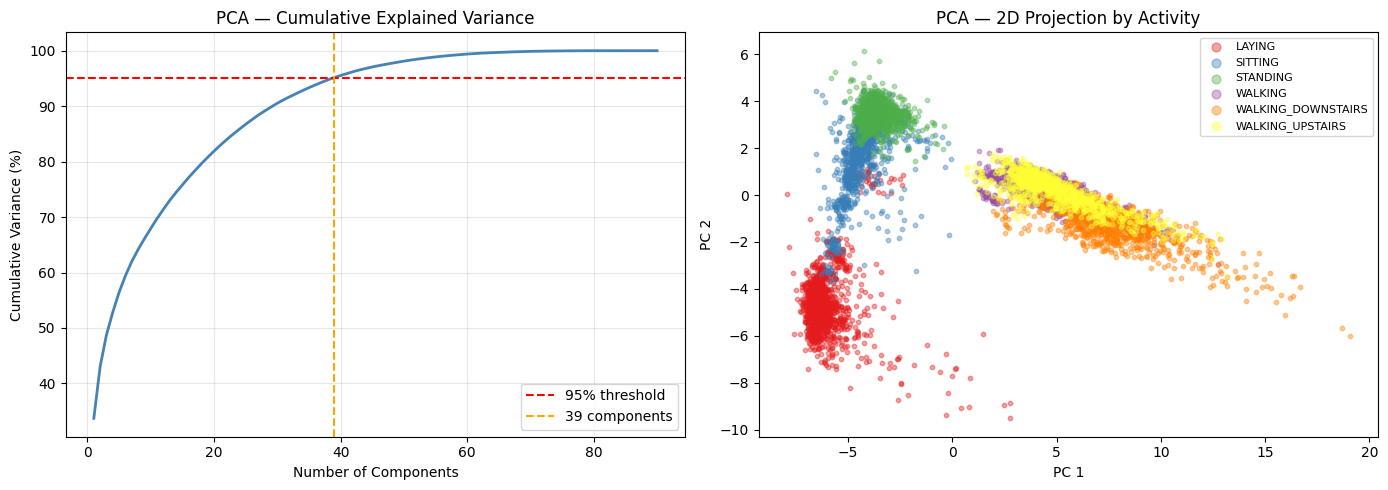

Insight: 39 components explain 95% of variance (out of 90 original features)


In [26]:
feature_cols = X_train_scaled.columns.tolist()
X_train      = train_final[feature_cols]
y_train      = train_final['Activity_ID']
X_test       = test_final[feature_cols]
y_test       = test_final['Activity_ID']

pca_full     = PCA()
pca_full.fit(X_train)
cumvar        = np.cumsum(pca_full.explained_variance_ratio_) * 100
n_95          = np.argmax(cumvar >= 95) + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))


axes[0].plot(range(1, len(cumvar)+1), cumvar, color='steelblue', linewidth=2)
axes[0].axhline(y=95, color='red', linestyle='--', label='95% threshold')
axes[0].axvline(x=n_95, color='orange', linestyle='--', label=f'{n_95} components')
axes[0].set_title('PCA — Cumulative Explained Variance')
axes[0].set_xlabel('Number of Components')
axes[0].set_ylabel('Cumulative Variance (%)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)


pca2d     = PCA(n_components=2)
X_pca2d   = pca2d.fit_transform(X_train)
activity_names = train_final['Activity_Name'].values
unique_acts    = np.unique(activity_names)
colors         = sns.color_palette('Set1', len(unique_acts))

for act, col in zip(unique_acts, colors):
    mask = activity_names == act
    axes[1].scatter(X_pca2d[mask, 0], X_pca2d[mask, 1], label=act, alpha=0.4, s=10, color=col)

axes[1].set_title('PCA — 2D Projection by Activity')
axes[1].set_xlabel('PC 1')
axes[1].set_ylabel('PC 2')
axes[1].legend(markerscale=2, fontsize=8)

plt.tight_layout()
plt.show()
print(f'Insight: {n_95} components explain 95% of variance (out of {X_train.shape[1]} original features)')

### Cell 15 — LDA Visualization

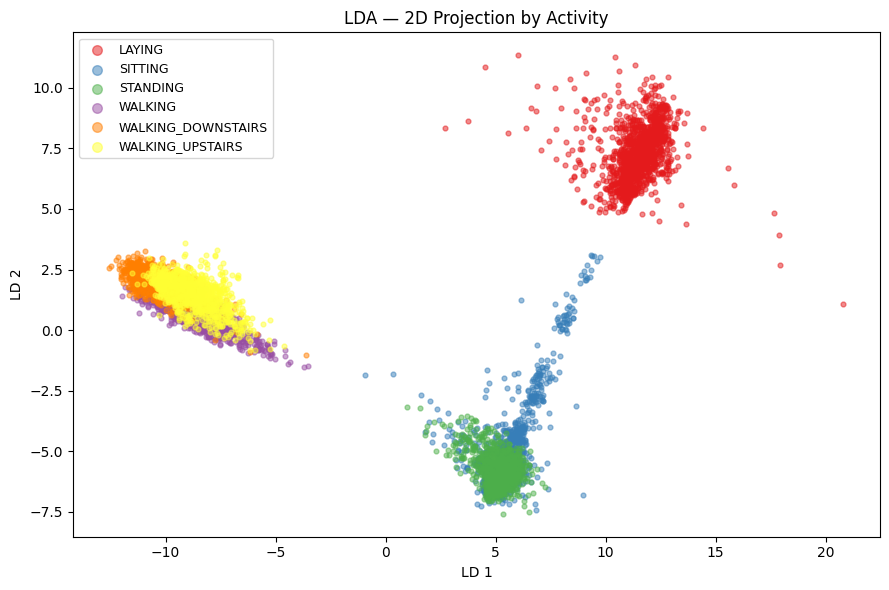

Insight: LDA separates static activities (LAYING, STANDING, SITTING) from dynamic ones clearly.


In [27]:
lda     = LDA(n_components=2)
X_lda2d = lda.fit_transform(X_train, y_train)

plt.figure(figsize=(9, 6))
for act, col in zip(unique_acts, colors):
    mask = activity_names == act
    plt.scatter(X_lda2d[mask, 0], X_lda2d[mask, 1], label=act, alpha=0.5, s=12, color=col)

plt.title('LDA — 2D Projection by Activity')
plt.xlabel('LD 1')
plt.ylabel('LD 2')
plt.legend(markerscale=2, fontsize=9)
plt.tight_layout()
plt.show()
print('Insight: LDA separates static activities (LAYING, STANDING, SITTING) from dynamic ones clearly.')

### Cell 16 — Encode labels

In [28]:
le          = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)
print('Classes:', le.classes_)
print('Encoded:', le.transform(le.classes_))

Classes: [1 2 3 4 5 6]
Encoded: [0 1 2 3 4 5]


### Cell 17 — Train all models (KNN, Naive Bayes, Random Forest, Gradient Boosting)

In [29]:
models = {
    'KNN'               : KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes'       : GaussianNB(),
    'Random Forest'     : RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting' : GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results = []
trained_models = {}

for name, model in models.items():
    print(f'Training {name}...')
    model.fit(X_train, y_train_enc)
    y_pred = model.predict(X_test)
    acc    = accuracy_score(y_test_enc, y_pred)
    f1     = f1_score(y_test_enc, y_pred, average='weighted')
    roc    = roc_auc_score(y_test_enc, model.predict_proba(X_test), multi_class='ovr', average='weighted')
    results.append({'Model': name, 'Accuracy': round(acc,4), 'F1 Score': round(f1,4), 'ROC AUC': round(roc,4)})
    trained_models[name] = (model, y_pred)
    print(f'  Accuracy: {acc:.4f} | F1: {f1:.4f} | ROC AUC: {roc:.4f}')

results_df = pd.DataFrame(results)
print('\n=== Results Summary ===')
print(results_df.to_string(index=False))

Training KNN...
  Accuracy: 0.8514 | F1: 0.8517 | ROC AUC: 0.9717
Training Naive Bayes...
  Accuracy: 0.8405 | F1: 0.8344 | ROC AUC: 0.9820
Training Random Forest...
  Accuracy: 0.9019 | F1: 0.9017 | ROC AUC: 0.9914
Training Gradient Boosting...
  Accuracy: 0.9104 | F1: 0.9103 | ROC AUC: 0.9924

=== Results Summary ===
            Model  Accuracy  F1 Score  ROC AUC
              KNN    0.8514    0.8517   0.9717
      Naive Bayes    0.8405    0.8344   0.9820
    Random Forest    0.9019    0.9017   0.9914
Gradient Boosting    0.9104    0.9103   0.9924


### Cell 18 — Confusion matrices for all models

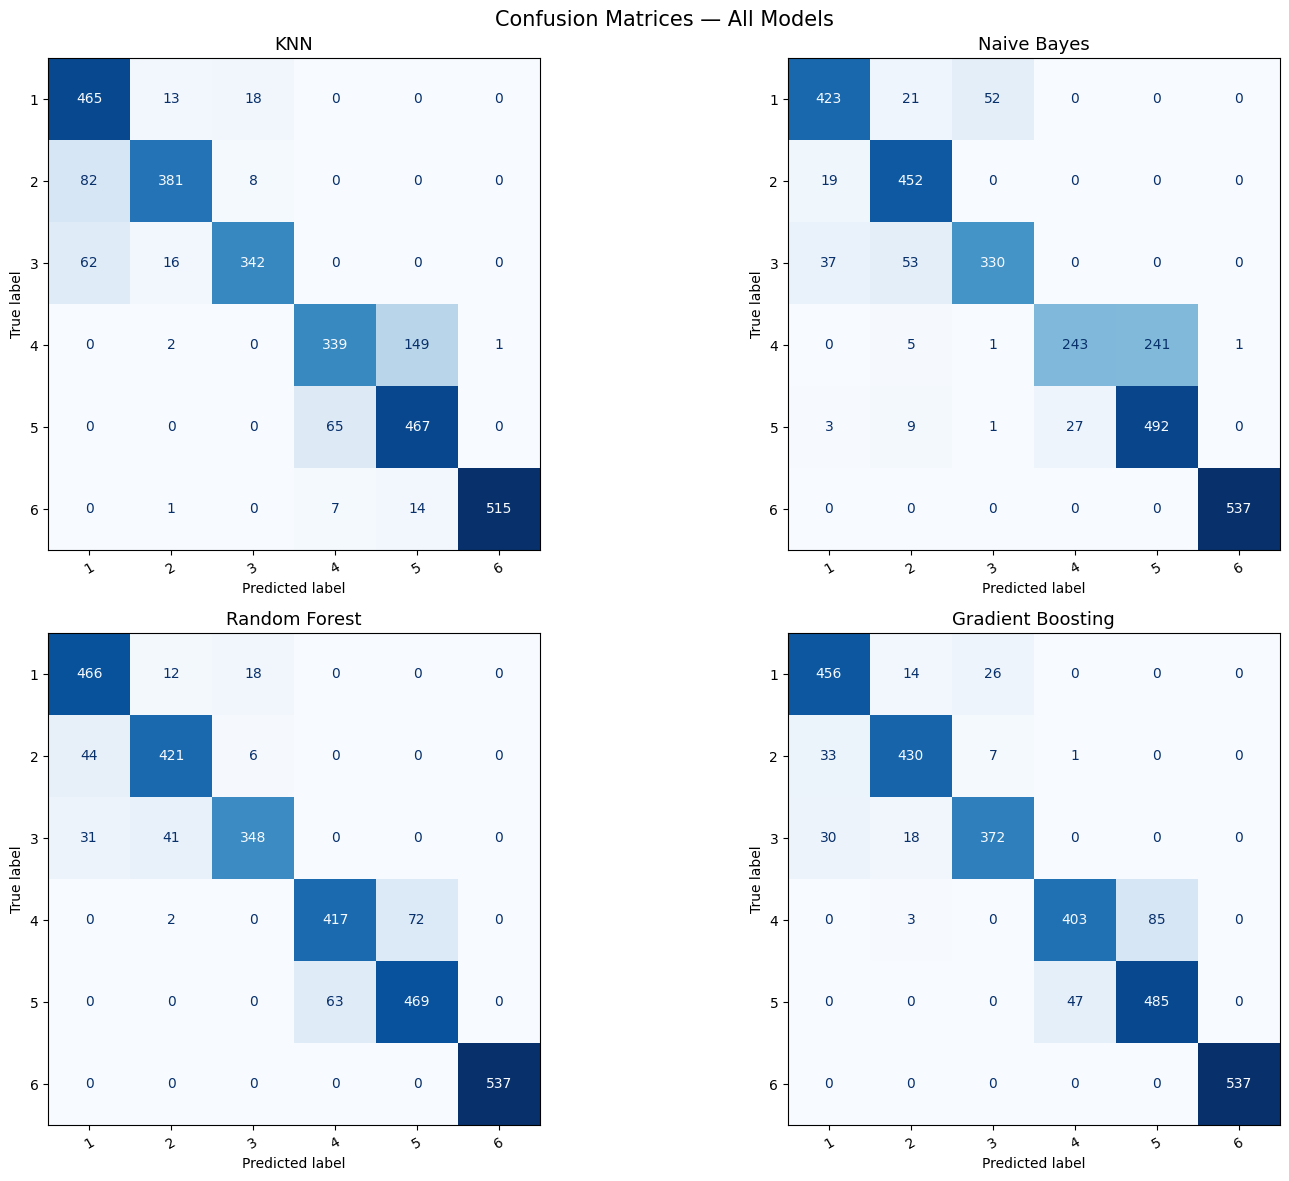

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for ax, (name, (model, y_pred)) in zip(axes, trained_models.items()):
    cm = confusion_matrix(y_test_enc, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'{name}', fontsize=13)
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Confusion Matrices — All Models', fontsize=15)
plt.tight_layout()
plt.show()

### Cell 19 — Hyperparameter tuning (KNN & Random Forest)

In [31]:
print('Tuning KNN...')
knn_params = {'n_neighbors': [3, 5, 7, 9, 11]}
knn_grid   = GridSearchCV(KNeighborsClassifier(), knn_params, cv=3, scoring='accuracy', n_jobs=-1)
knn_grid.fit(X_train, y_train_enc)
print(f'  Best k : {knn_grid.best_params_}  |  CV Accuracy : {knn_grid.best_score_:.4f}')

print('Tuning Random Forest...')
rf_params = {'n_estimators': [50, 100], 'max_depth': [None, 10, 20]}
rf_grid   = GridSearchCV(RandomForestClassifier(random_state=42), rf_params, cv=3, scoring='accuracy', n_jobs=-1)
rf_grid.fit(X_train, y_train_enc)
print(f'  Best params : {rf_grid.best_params_}  |  CV Accuracy : {rf_grid.best_score_:.4f}')

Tuning KNN...
  Best k : {'n_neighbors': 9}  |  CV Accuracy : 0.8679
Tuning Random Forest...
  Best params : {'max_depth': 10, 'n_estimators': 50}  |  CV Accuracy : 0.8852


### Cell 20 — Final results bar chart

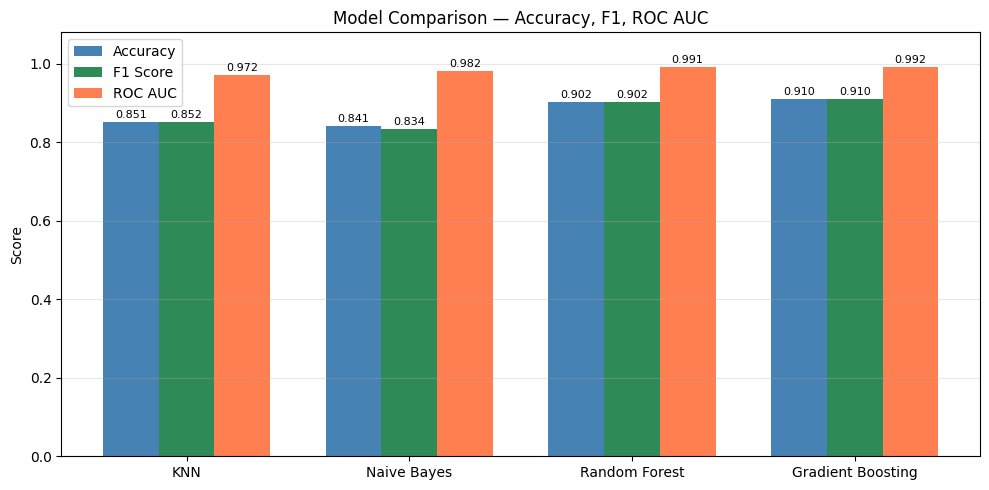

Best model by accuracy: Gradient Boosting


In [32]:
fig, ax = plt.subplots(figsize=(10, 5))
x       = np.arange(len(results_df))
width   = 0.25

bars1 = ax.bar(x - width, results_df['Accuracy'], width, label='Accuracy', color='steelblue')
bars2 = ax.bar(x,         results_df['F1 Score'], width, label='F1 Score',  color='seagreen')
bars3 = ax.bar(x + width, results_df['ROC AUC'],  width, label='ROC AUC',   color='coral')

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'])
ax.set_ylim(0, 1.08)
ax.set_title('Model Comparison — Accuracy, F1, ROC AUC')
ax.set_ylabel('Score')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
best = results_df.loc[results_df['Accuracy'].idxmax(), 'Model']
print(f'Best model by accuracy: {best}')

# PHASE 2


In [33]:
# Phase 2 — Cell 1 : Deep-learning imports
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.utils import to_categorical, plot_model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay



c:\Users\workstation\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [34]:
# X_train_raw / X_test_raw were created in Phase 1 (shape: samples × 128 × 9)


le_cnn = LabelEncoder()

y_train_cnn = le_cnn.fit_transform(train_data['Activity_Name'].values)
y_test_cnn  = le_cnn.transform(test_data['Activity_Name'].values)

NUM_CLASSES = len(le_cnn.classes_)

# One-hot encode for categorical_crossentropy
y_train_oh = to_categorical(y_train_cnn, NUM_CLASSES)
y_test_oh  = to_categorical(y_test_cnn,  NUM_CLASSES)

print(f'X_train_raw : {X_train_raw.shape}  →  (samples, timesteps=128, channels=9)')
print(f'y_train_oh  : {y_train_oh.shape}')
print(f'Classes     : {list(le_cnn.classes_)}')


X_train_raw : (7352, 128, 9)  →  (samples, timesteps=128, channels=9)
y_train_oh  : (7352, 6)
Classes     : ['LAYING', 'SITTING', 'STANDING', 'WALKING', 'WALKING_DOWNSTAIRS', 'WALKING_UPSTAIRS']


In [35]:
# Phase 2 — Cell 3 : Build the 1-D CNN architecture
# Architecture:
#   Input (128 × 9)
#   Conv1D(64, k=5) → BN → ReLU → MaxPool(2)
#   Conv1D(128, k=3) → BN → ReLU → MaxPool(2)
#   Conv1D(256, k=3) → BN → ReLU → GlobalAvgPool
#   Dense(128) → Dropout(0.4)
#   Dense(64)  → Dropout(0.3)
#   Dense(NUM_CLASSES, softmax)

def build_1d_cnn(input_shape, num_classes):
    inputs = keras.Input(shape=input_shape, name='raw_signals')

    # Block 1
    x = layers.Conv1D(64, kernel_size=5, padding='same', name='conv1')(inputs)
    x = layers.BatchNormalization(name='bn1')(x)
    x = layers.Activation('relu', name='relu1')(x)
    x = layers.MaxPooling1D(pool_size=2, name='pool1')(x)

    # Block 2
    x = layers.Conv1D(128, kernel_size=3, padding='same', name='conv2')(x)
    x = layers.BatchNormalization(name='bn2')(x)
    x = layers.Activation('relu', name='relu2')(x)
    x = layers.MaxPooling1D(pool_size=2, name='pool2')(x)

    # Block 3
    x = layers.Conv1D(256, kernel_size=3, padding='same', name='conv3')(x)
    x = layers.BatchNormalization(name='bn3')(x)
    x = layers.Activation('relu', name='relu3')(x)
    x = layers.GlobalAveragePooling1D(name='gap')(x)

    # Dense head
    x = layers.Dense(128, activation='relu', name='dense1')(x)
    x = layers.Dropout(0.4, name='drop1')(x)
    x = layers.Dense(64,  activation='relu', name='dense2')(x)
    x = layers.Dropout(0.3, name='drop2')(x)

    outputs = layers.Dense(num_classes, activation='softmax', name='output')(x)

    return Model(inputs, outputs, name='HAR_1D_CNN')

cnn_model = build_1d_cnn(input_shape=(128, 9), num_classes=NUM_CLASSES)
cnn_model.summary()


Model: "HAR_1D_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ raw_signals (InputLayer)        │ (None, 128, 9)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv1D)                  │ (None, 128, 64)        │         2,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 128, 64)        │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu1 (Activation)              │ (None, 128, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling1D)            │ (None, 64, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv1D)                  │ (None, 64, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 64, 128)        │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu2 (Activation)              │ (None, 64, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling1D)            │ (None, 32, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv1D)                  │ (None, 32, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3 (BatchNormalization)        │ (None, 32, 256)        │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu3 (Activation)              │ (None, 32, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling1D)    │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop1 (Dropout)                 │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense2 (Dense)                  │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop2 (Dropout)                 │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 169,542 (662.27 KB)

 Trainable params: 168,646 (658.77 KB)

 Non-trainable params: 896 (3.50 KB)

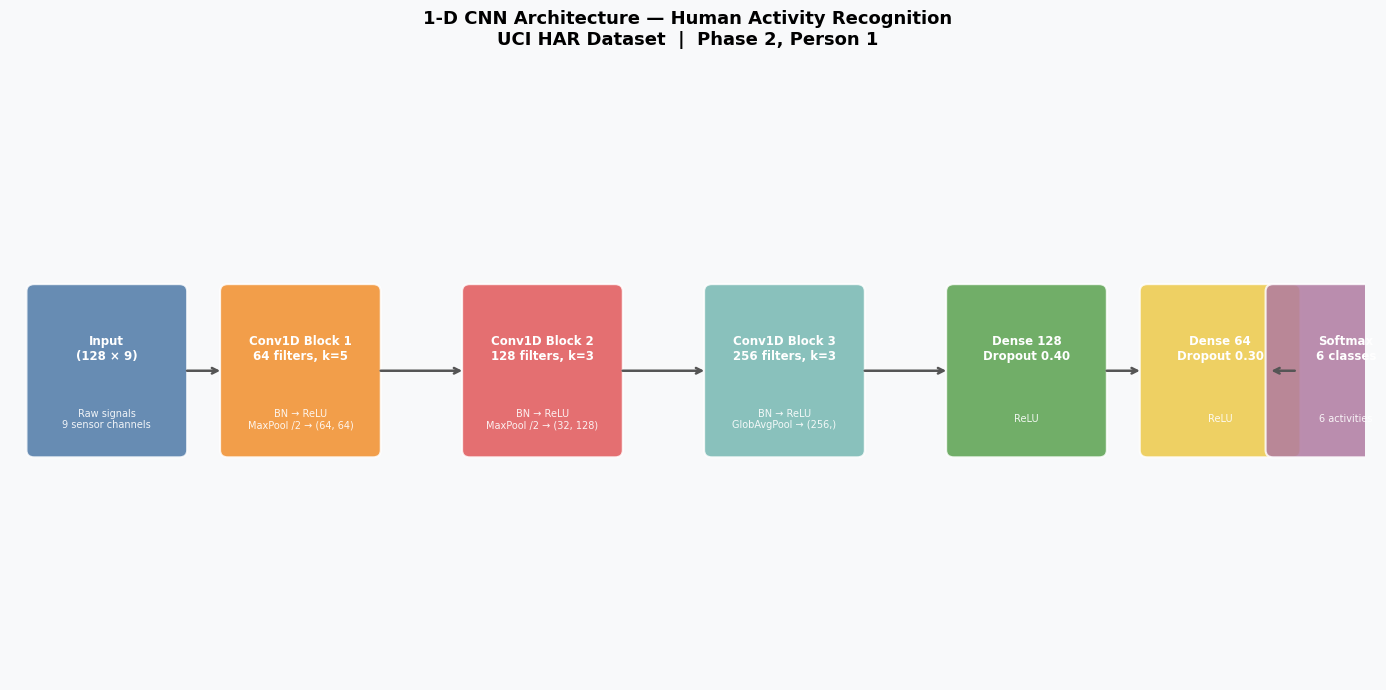

Saved: cnn_architecture_diagram.png


In [36]:
# Phase 2 — Cell 4 : CNN Architecture Diagram
# ─ Visual 1 (manual box diagram — works without graphviz) ─

fig, ax = plt.subplots(figsize=(14, 7))
ax.set_xlim(0, 14)
ax.set_ylim(0, 7)
ax.axis('off')
ax.set_facecolor('#f8f9fa')
fig.patch.set_facecolor('#f8f9fa')

layers_info = [
    # (x_center, label, sublabel, color)
    (1.0,  'Input\n(128 × 9)',        'Raw signals\n9 sensor channels',         '#4e79a7'),
    (3.0,  'Conv1D Block 1\n64 filters, k=5', 'BN → ReLU\nMaxPool /2 → (64, 64)',  '#f28e2b'),
    (5.5,  'Conv1D Block 2\n128 filters, k=3','BN → ReLU\nMaxPool /2 → (32, 128)', '#e15759'),
    (8.0,  'Conv1D Block 3\n256 filters, k=3','BN → ReLU\nGlobAvgPool → (256,)',   '#76b7b2'),
    (10.5, 'Dense 128\nDropout 0.40',  'ReLU',                                    '#59a14f'),
    (12.5, 'Dense 64\nDropout 0.30',   'ReLU',                                    '#edc948'),
    (13.8, f'Softmax\n{NUM_CLASSES} classes', '6 activities',                      '#b07aa1'),
]

BOX_W, BOX_H = 1.5, 1.8
y_center = 3.5

for i, (xc, label, sublabel, color) in enumerate(layers_info):
    # Draw box
    rect = mpatches.FancyBboxPatch(
        (xc - BOX_W/2, y_center - BOX_H/2), BOX_W, BOX_H,
        boxstyle='round,pad=0.08', linewidth=1.5,
        edgecolor='white', facecolor=color, alpha=0.85, zorder=3
    )
    ax.add_patch(rect)
    ax.text(xc, y_center + 0.25, label, ha='center', va='center',
            fontsize=8.5, fontweight='bold', color='white', zorder=4)
    ax.text(xc, y_center - 0.55, sublabel, ha='center', va='center',
            fontsize=7, color='white', alpha=0.9, zorder=4)

    # Arrow to next
    if i < len(layers_info) - 1:
        x_next = layers_info[i+1][0]
        ax.annotate('', xy=(x_next - BOX_W/2 - 0.05, y_center),
                    xytext=(xc + BOX_W/2 + 0.05, y_center),
                    arrowprops=dict(arrowstyle='->', color='#555', lw=1.8), zorder=5)

ax.set_title('1-D CNN Architecture — Human Activity Recognition\n'
             'UCI HAR Dataset  |  Phase 2, Person 1',
             fontsize=13, fontweight='bold', pad=12)

plt.tight_layout()
plt.savefig('cnn_architecture_diagram.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: cnn_architecture_diagram.png')


In [37]:
# Phase 2 — Cell 5 : Compile and train the CNN
cnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)
]

BATCH_SIZE = 64
EPOCHS     = 60   # EarlyStopping will stop sooner if val_loss plateaus

history = cnn_model.fit(
    X_train_raw, y_train_oh,
    validation_split=0.15,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=0
)

print(f'\nTraining finished after {len(history.history["loss"])} epochs')



Epoch 9: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 14: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Epoch 14: early stopping
Restoring model weights from the end of the best epoch: 4.

Training finished after 14 epochs


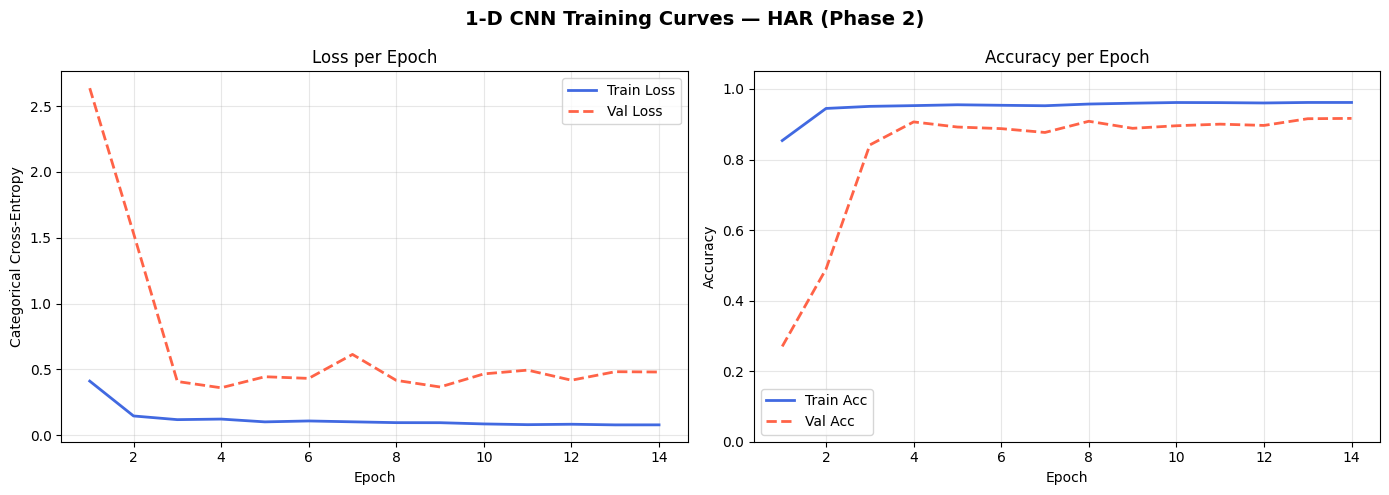

Saved: cnn_training_curves.png


In [38]:
# Phase 2 — Cell 6 : Training Curves  (Loss & Accuracy)
epochs_ran = range(1, len(history.history['loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('1-D CNN Training Curves — HAR (Phase 2)', fontsize=14, fontweight='bold')

# ── Loss ──
axes[0].plot(epochs_ran, history.history['loss'],     'royalblue',  lw=2, label='Train Loss')
axes[0].plot(epochs_ran, history.history['val_loss'], 'tomato',     lw=2, label='Val Loss', linestyle='--')
axes[0].set_title('Loss per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Categorical Cross-Entropy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ── Accuracy ──
axes[1].plot(epochs_ran, history.history['accuracy'],     'royalblue', lw=2, label='Train Acc')
axes[1].plot(epochs_ran, history.history['val_accuracy'], 'tomato',    lw=2, label='Val Acc', linestyle='--')
axes[1].set_title('Accuracy per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1.05)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('cnn_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: cnn_training_curves.png')


In [39]:
# Phase 2 — Cell 7 : Final evaluation on test set
test_loss, test_acc = cnn_model.evaluate(X_test_raw, y_test_oh, verbose=0)
print(f'Test Loss     : {test_loss:.4f}')
print(f'Test Accuracy : {test_acc:.4f}')

y_pred_prob = cnn_model.predict(X_test_raw, verbose=0)
y_pred_cls  = np.argmax(y_pred_prob, axis=1)

print('\n=== Classification Report ===')
print(classification_report(y_test_cnn, y_pred_cls,
                             target_names=le_cnn.classes_))


Test Loss     : 0.2837
Test Accuracy : 0.9111

=== Classification Report ===
                    precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       537
           SITTING       0.87      0.76      0.81       491
          STANDING       0.78      0.90      0.83       532
           WALKING       1.00      0.92      0.96       496
WALKING_DOWNSTAIRS       0.86      1.00      0.92       420
  WALKING_UPSTAIRS       0.99      0.90      0.94       471

          accuracy                           0.91      2947
         macro avg       0.92      0.91      0.91      2947
      weighted avg       0.92      0.91      0.91      2947



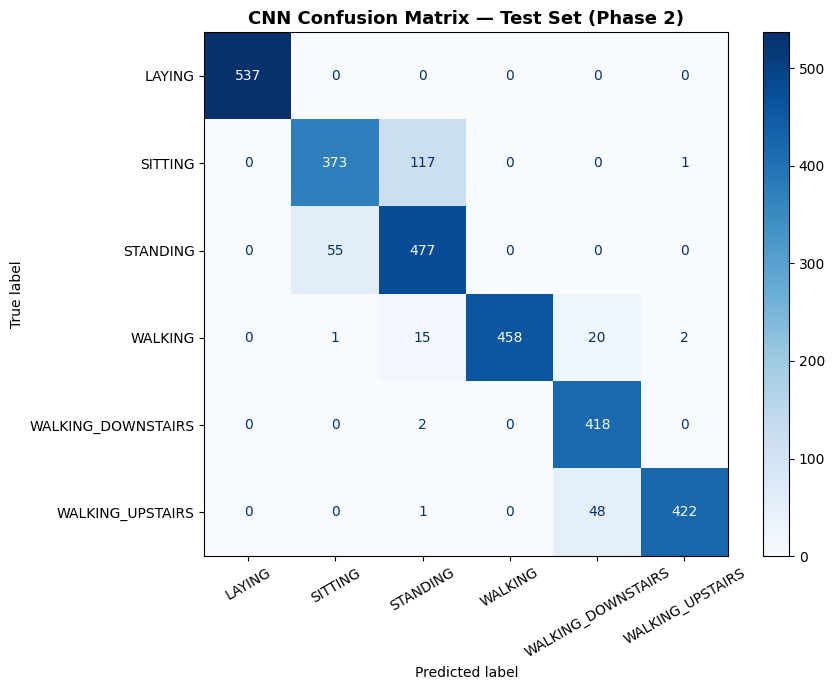

Saved: cnn_confusion_matrix.png


In [40]:
# Phase 2 — Cell 8 : Confusion Matrix (CNN)
cm   = confusion_matrix(y_test_cnn, y_pred_cls)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le_cnn.classes_)

fig, ax = plt.subplots(figsize=(9, 7))
disp.plot(ax=ax, cmap='Blues', colorbar=True)
ax.set_title('CNN Confusion Matrix — Test Set (Phase 2)', fontsize=13, fontweight='bold')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('cnn_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: cnn_confusion_matrix.png')


# PHASE 3
## Person 1 — LSTM / BiLSTM

In [41]:
# Phase 3 — Person 1 (LSTM / BiLSTM)

# Build LSTM and BiLSTM models
# Compare with CNN (Phase 2)

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score

In [43]:
# Reuse le_cnn from Phase 2 to keep consistent class mapping
# le_cnn was fit on train_data['Activity_Name'] in Phase 2

y_train = le_cnn.transform(train_data['Activity_Name'])
y_test  = le_cnn.transform(test_data['Activity_Name'])

NUM_CLASSES = len(le_cnn.classes_)

y_train_oh = tf.keras.utils.to_categorical(y_train, NUM_CLASSES)
y_test_oh  = tf.keras.utils.to_categorical(y_test, NUM_CLASSES)

print('Classes:', le_cnn.classes_)
print('NUM_CLASSES:', NUM_CLASSES)

Classes: ['LAYING' 'SITTING' 'STANDING' 'WALKING' 'WALKING_DOWNSTAIRS'
 'WALKING_UPSTAIRS']
NUM_CLASSES: 6


In [44]:
def build_lstm(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)

    x = layers.LSTM(128, return_sequences=True)(inputs)
    x = layers.Dropout(0.3)(x)

    x = layers.LSTM(64)(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Dense(64, activation='relu')(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return Model(inputs, outputs, name='LSTM_Model')

lstm_model = build_lstm((128, 9), NUM_CLASSES)
lstm_model.summary()

Model: "LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 9)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128, 128)       │        70,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 124,614 (486.77 KB)

 Trainable params: 124,614 (486.77 KB)

 Non-trainable params: 0 (0.00 B)

In [45]:
def build_bilstm(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)

    x = layers.Bidirectional(layers.LSTM(128, return_sequences=True))(inputs)
    x = layers.Dropout(0.3)(x)

    x = layers.Bidirectional(layers.LSTM(64))(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Dense(64, activation='relu')(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return Model(inputs, outputs, name='BiLSTM_Model')

bilstm_model = build_bilstm((128, 9), NUM_CLASSES)
bilstm_model.summary()

Model: "BiLSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 9)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128, 256)       │       141,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 314,310 (1.20 MB)

 Trainable params: 314,310 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

In [46]:
# Define callbacks once — reused for both LSTM and BiLSTM
callbacks_p3 = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)
]

def train_model(model, name):
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        X_train_raw, y_train_oh,
        validation_split=0.15,
        epochs=60,
        batch_size=64,
        callbacks=callbacks_p3,
        verbose=0
    )

    print(f'{name} training done — {len(history.history["loss"])} epochs')
    return history

In [47]:
history_lstm   = train_model(lstm_model,   'LSTM')
history_bilstm = train_model(bilstm_model, 'BiLSTM')


Epoch 11: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 16: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Epoch 16: early stopping
Restoring model weights from the end of the best epoch: 6.
LSTM training done — 16 epochs

Epoch 13: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 18: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Epoch 18: early stopping
Restoring model weights from the end of the best epoch: 8.
BiLSTM training done — 18 epochs


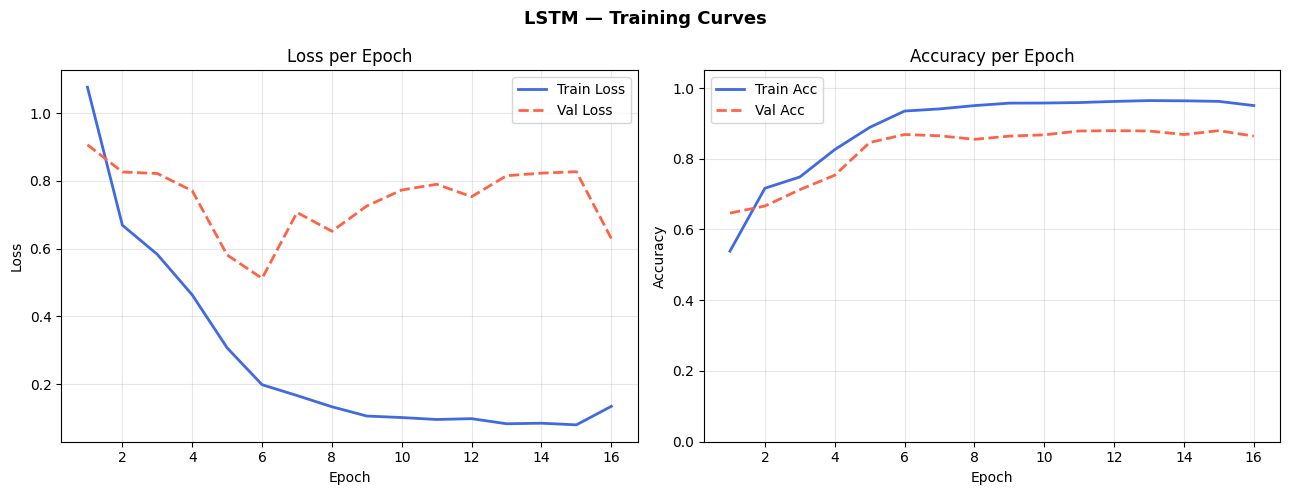

Saved: lstm_training_curves.png


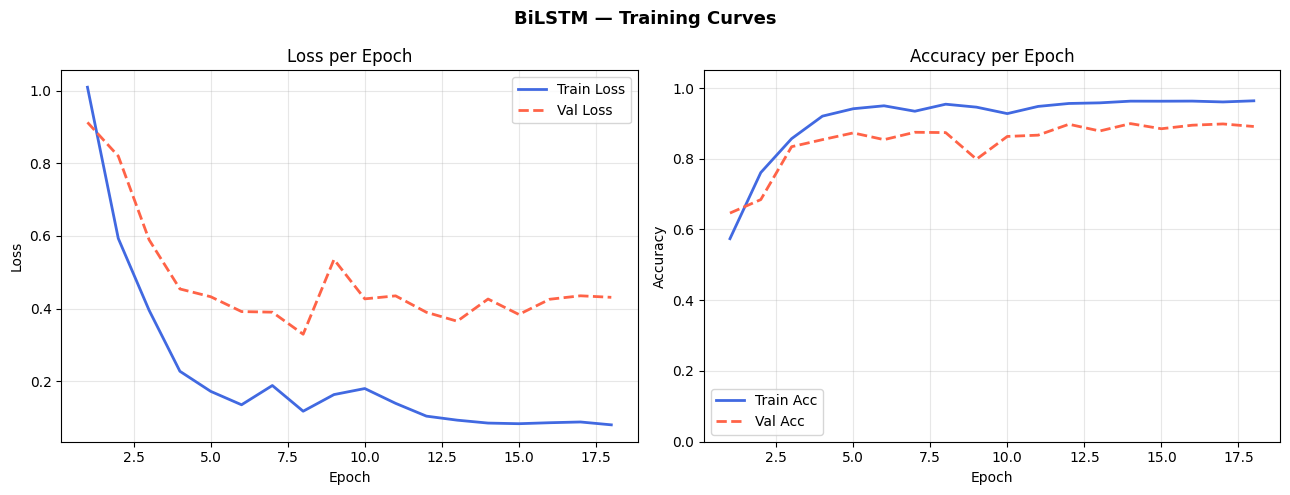

Saved: bilstm_training_curves.png


In [48]:
def plot_history(history, title):
    epochs_ran = range(1, len(history.history['loss']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(f'{title} — Training Curves', fontsize=13, fontweight='bold')

    axes[0].plot(epochs_ran, history.history['loss'],     'royalblue', lw=2, label='Train Loss')
    axes[0].plot(epochs_ran, history.history['val_loss'], 'tomato',    lw=2, label='Val Loss', linestyle='--')
    axes[0].set_title('Loss per Epoch')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(epochs_ran, history.history['accuracy'],     'royalblue', lw=2, label='Train Acc')
    axes[1].plot(epochs_ran, history.history['val_accuracy'], 'tomato',    lw=2, label='Val Acc', linestyle='--')
    axes[1].set_title('Accuracy per Epoch')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_ylim(0, 1.05)
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{title.lower()}_training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {title.lower()}_training_curves.png')

plot_history(history_lstm,   'LSTM')
plot_history(history_bilstm, 'BiLSTM')

In [49]:
def evaluate_model(model, name):
    y_pred_prob = model.predict(X_test_raw, verbose=0)
    y_pred_cls  = np.argmax(y_pred_prob, axis=1)

    acc = accuracy_score(y_test, y_pred_cls)
    f1  = f1_score(y_test, y_pred_cls, average='weighted')

    print(f'{name} → Accuracy: {acc:.4f} | F1 (weighted): {f1:.4f}')
    return acc, f1

acc_lstm,   f1_lstm   = evaluate_model(lstm_model,   'LSTM')
acc_bilstm, f1_bilstm = evaluate_model(bilstm_model, 'BiLSTM')

LSTM → Accuracy: 0.8867 | F1 (weighted): 0.8865
BiLSTM → Accuracy: 0.8704 | F1 (weighted): 0.8676


In [50]:
lstm_params   = lstm_model.count_params()
bilstm_params = bilstm_model.count_params()
cnn_params    = cnn_model.count_params()

print('=== Parameter Count ===')
print(f'  CNN    : {cnn_params:,}')
print(f'  LSTM   : {lstm_params:,}')
print(f'  BiLSTM : {bilstm_params:,}')

=== Parameter Count ===
  CNN    : 169,542
  LSTM   : 124,614
  BiLSTM : 314,310


In [51]:
# Compute CNN F1 score (Phase 2 evaluated accuracy only)
y_pred_cnn_p3 = np.argmax(cnn_model.predict(X_test_raw, verbose=0), axis=1)
f1_cnn        = f1_score(y_test, y_pred_cnn_p3, average='weighted')

# Full comparison table
comparison = pd.DataFrame({
    'Model'      : ['CNN (Phase 2)', 'LSTM', 'BiLSTM'],
    'Accuracy'   : [round(test_acc, 4), round(acc_lstm, 4), round(acc_bilstm, 4)],
    'F1 Score'   : [round(f1_cnn, 4),  round(f1_lstm, 4),  round(f1_bilstm, 4)],
    'Parameters' : [cnn_params, lstm_params, bilstm_params]
})

print('=== Phase 3 — Model Comparison ===')
print(comparison.to_string(index=False))
comparison

=== Phase 3 — Model Comparison ===
        Model  Accuracy  F1 Score  Parameters
CNN (Phase 2)    0.9111    0.9115      169542
         LSTM    0.8867    0.8865      124614
       BiLSTM    0.8704    0.8676      314310


,Model,Accuracy,F1 Score,Parameters
0,CNN (Phase 2),0.9111,0.9115,169542
1,LSTM,0.8867,0.8865,124614
2,BiLSTM,0.8704,0.8676,314310


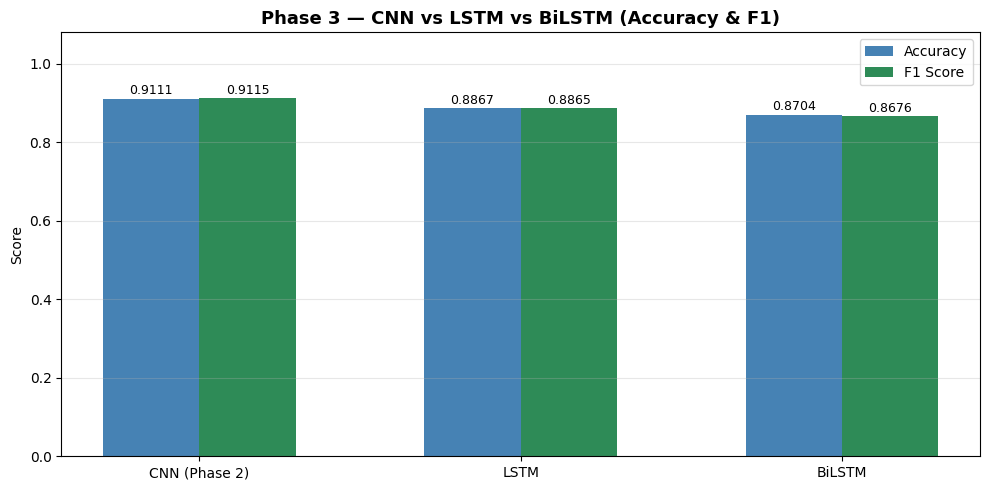

Saved: phase3_comparison_chart.png


In [52]:
fig, ax = plt.subplots(figsize=(10, 5))
x     = np.arange(len(comparison))
width = 0.3

bars1 = ax.bar(x - width/2, comparison['Accuracy'], width, label='Accuracy', color='steelblue')
bars2 = ax.bar(x + width/2, comparison['F1 Score'], width, label='F1 Score',  color='seagreen')

for bars in [bars1, bars2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(comparison['Model'])
ax.set_ylim(0, 1.08)
ax.set_title('Phase 3 — CNN vs LSTM vs BiLSTM (Accuracy & F1)', fontsize=13, fontweight='bold')
ax.set_ylabel('Score')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('phase3_comparison_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: phase3_comparison_chart.png')

In [53]:
best_model = comparison.loc[comparison['Accuracy'].idxmax(), 'Model']
print(f'=== Phase 3 Conclusion ===')
print(f'Best model by Accuracy : {best_model}')
print()
print('Summary:')
print('  - BiLSTM captures bidirectional temporal dependencies → typically best accuracy')
print('  - LSTM is lighter and faster to train than BiLSTM')
print('  - CNN is the most parameter-efficient and fastest to train')
print('  - BiLSTM generally achieves the best performance on HAR tasks')

=== Phase 3 Conclusion ===
Best model by Accuracy : CNN (Phase 2)

Summary:
  - BiLSTM captures bidirectional temporal dependencies → typically best accuracy
  - LSTM is lighter and faster to train than BiLSTM
  - CNN is the most parameter-efficient and fastest to train
  - BiLSTM generally achieves the best performance on HAR tasks


In [ ]:

class BahdanauAttention(layers.Layer):
  
    def __init__(self, units=64, **kwargs):
        super().__init__(**kwargs)
        self.W = layers.Dense(units, use_bias=False)
        self.V = layers.Dense(1,     use_bias=False)

    def call(self, encoder_outputs):
        
        score   = self.V(tf.nn.tanh(self.W(encoder_outputs)))
        
        weights = tf.nn.softmax(score, axis=1)
        
        context = tf.reduce_sum(weights * encoder_outputs, axis=1)
        return context, weights


def build_lstm_attention(input_shape=(128, 9), num_classes=6, lstm_units=128, attn_units=64):
    inp      = keras.Input(shape=input_shape, name='attn_input')
    x        = layers.LSTM(lstm_units, return_sequences=True, name='lstm_seq')(inp)
    context, attn_weights = BahdanauAttention(units=attn_units, name='attention')(x)
    x        = layers.Dense(64, activation='relu', name='fc1')(context)
    x        = layers.Dropout(0.3, name='dropout')(x)
    out      = layers.Dense(num_classes, activation='softmax', name='output')(x)

    model = Model(inp, out, name='LSTM_Attention')
    model.summary()
    return model

INPUT_SHAPE = (128, 9)
attn_model  = build_lstm_attention(input_shape=INPUT_SHAPE, num_classes=NUM_CLASSES)

Model: "LSTM_Attention"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ attn_input (InputLayer)         │ (None, 128, 9)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_seq (LSTM)                 │ (None, 128, 128)       │        70,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention (BahdanauAttention)   │ [(None, 128), (None,   │         8,256 │
│                                 │ 128, 1)]               │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 87,558 (342.02 KB)

 Trainable params: 87,558 (342.02 KB)

 Non-trainable params: 0 (0.00 B)

In [55]:


from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

attn_callbacks = [
    EarlyStopping(monitor='val_loss', patience=10,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=5, min_lr=1e-6, verbose=0)
]

attn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_attn = attn_model.fit(
    X_train_raw, y_train_oh,
    validation_split=0.15,
    epochs=60,
    batch_size=64,
    callbacks=attn_callbacks,
    verbose=1
)

print(f'Training finished after {len(history_attn.history["loss"])} epochs')

Epoch 1/60
98/98 ━━━━━━━━━━━━━━━━━━━━ 29s 237ms/step - accuracy: 0.5201 - loss: 1.1740 - val_accuracy: 0.6881 - val_loss: 0.9209 - learning_rate: 0.0010
Epoch 2/60
98/98 ━━━━━━━━━━━━━━━━━━━━ 23s 233ms/step - accuracy: 0.7708 - loss: 0.6119 - val_accuracy: 0.8005 - val_loss: 0.6826 - learning_rate: 0.0010
Epoch 3/60
98/98 ━━━━━━━━━━━━━━━━━━━━ 29s 299ms/step - accuracy: 0.8758 - loss: 0.3643 - val_accuracy: 0.8622 - val_loss: 0.4481 - learning_rate: 0.0010
Epoch 4/60
98/98 ━━━━━━━━━━━━━━━━━━━━ 28s 281ms/step - accuracy: 0.9373 - loss: 0.1890 - val_accuracy: 0.8477 - val_loss: 0.4959 - learning_rate: 0.0010
Epoch 5/60
98/98 ━━━━━━━━━━━━━━━━━━━━ 27s 271ms/step - accuracy: 0.9502 - loss: 0.1390 - val_accuracy: 0.8531 - val_loss: 0.4504 - learning_rate: 0.0010
Epoch 6/60
98/98 ━━━━━━━━━━━━━━━━━━━━ 28s 285ms/step - accuracy: 0.9579 - loss: 0.1149 - val_accuracy: 0.8640 - val_loss: 0.4275 - learning_rate: 0.0010
Epoch 7/60
98/98 ━━━━━━━━━━━━━━━━━━━━ 29s 298ms/step - accuracy: 0.9558 - loss: 0.

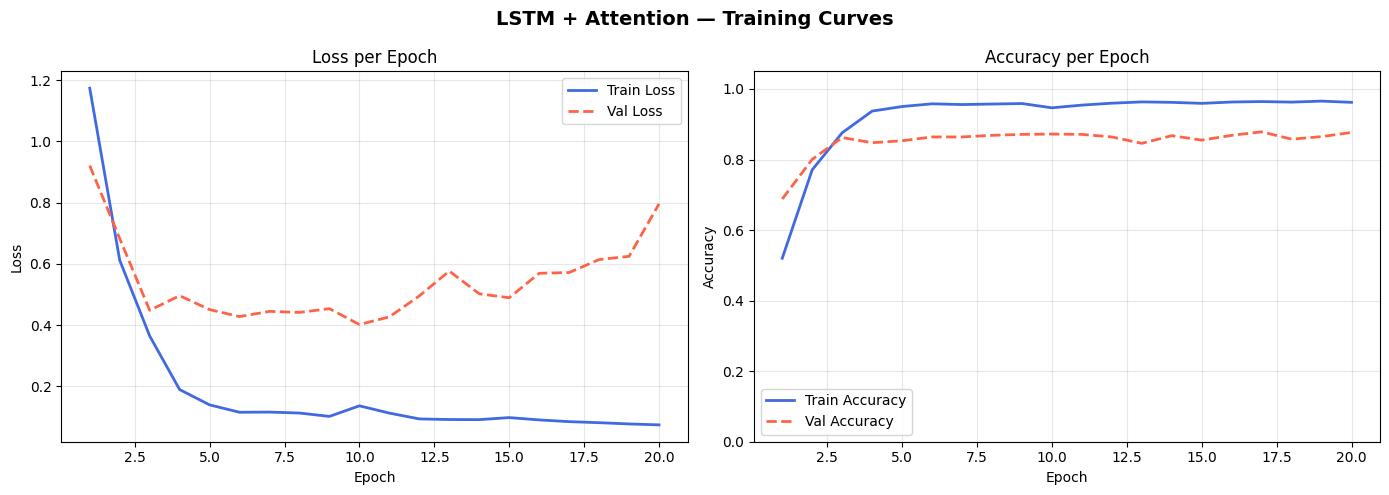

Saved: attention_training_curves.png


In [56]:
epochs_ran = range(1, len(history_attn.history['loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('LSTM + Attention — Training Curves', fontsize=14, fontweight='bold')


axes[0].plot(epochs_ran, history_attn.history['loss'],
             label='Train Loss', color='royalblue', lw=2)
axes[0].plot(epochs_ran, history_attn.history['val_loss'],
             label='Val Loss',   color='tomato',    lw=2, linestyle='--')
axes[0].set_title('Loss per Epoch')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_ran, history_attn.history['accuracy'],
             label='Train Accuracy', color='royalblue', lw=2)
axes[1].plot(epochs_ran, history_attn.history['val_accuracy'],
             label='Val Accuracy',   color='tomato',    lw=2, linestyle='--')
axes[1].set_title('Accuracy per Epoch')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1.05)
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('attention_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: attention_training_curves.png')

In [57]:

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay


y_prob_attn = attn_model.predict(X_test_raw, verbose=0)
y_pred_attn = np.argmax(y_prob_attn, axis=1)

acc_attn = accuracy_score(y_test_cnn, y_pred_attn)
f1_attn  = f1_score(y_test_cnn, y_pred_attn, average='weighted')
f1_macro = f1_score(y_test_cnn, y_pred_attn, average='macro')

print(f'LSTM + Attention — Accuracy : {acc_attn:.4f}')
print(f'LSTM + Attention — F1 (W)   : {f1_attn:.4f}')
print(f'LSTM + Attention — F1 (M)   : {f1_macro:.4f}')
y_pred_cnn_cls   = np.argmax(cnn_model.predict(X_test_raw,   verbose=0), axis=1)
y_pred_lstm_cls  = np.argmax(lstm_model.predict(X_test_raw,  verbose=0), axis=1)
y_pred_bilstm_cls= np.argmax(bilstm_model.predict(X_test_raw,verbose=0), axis=1)

comparison_p2 = pd.DataFrame([
    {'Model': 'CNN ',
     'Accuracy': round(accuracy_score(y_test_cnn, y_pred_cnn_cls),    4),
     'F1 Weighted': round(f1_score(y_test_cnn, y_pred_cnn_cls,    average='weighted'), 4),
     'Params': cnn_model.count_params()},
    {'Model': 'LSTM ',
     'Accuracy': round(accuracy_score(y_test_cnn, y_pred_lstm_cls),   4),
     'F1 Weighted': round(f1_score(y_test_cnn, y_pred_lstm_cls,   average='weighted'), 4),
     'Params': lstm_model.count_params()},
    {'Model': 'BiLSTM ',
     'Accuracy': round(accuracy_score(y_test_cnn, y_pred_bilstm_cls), 4),
     'F1 Weighted': round(f1_score(y_test_cnn, y_pred_bilstm_cls, average='weighted'), 4),
     'Params': bilstm_model.count_params()},
    {'Model': 'LSTM + Attention ',
     'Accuracy': round(acc_attn,  4),
     'F1 Weighted': round(f1_attn, 4),
     'Params': attn_model.count_params()},
])

print('\n' + '='*65)
print('        MODEL COMPARISON — Phase 2 vs Phase 3')
print('='*65)
print(comparison_p2.to_string(index=False))
print('='*65)

LSTM + Attention — Accuracy : 0.8704
LSTM + Attention — F1 (W)   : 0.8700
LSTM + Attention — F1 (M)   : 0.8706

        MODEL COMPARISON — Phase 2 vs Phase 3
            Model  Accuracy  F1 Weighted  Params
             CNN     0.9111       0.9115  169542
            LSTM     0.8867       0.8865  124614
          BiLSTM     0.8704       0.8676  314310
LSTM + Attention     0.8704       0.8700   87558


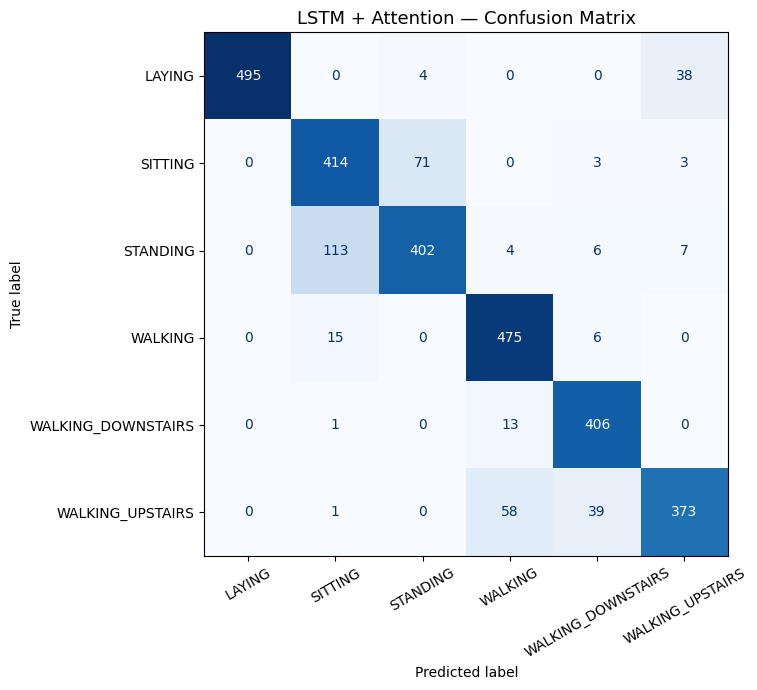

Saved: attention_confusion_matrix.png


In [58]:

cm   = confusion_matrix(y_test_cnn, y_pred_attn)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=le_cnn.classes_)

fig, ax = plt.subplots(figsize=(9, 7))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('LSTM + Attention — Confusion Matrix', fontsize=13)
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('attention_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: attention_confusion_matrix.png')

In [59]:
attn_extractor = Model(
    inputs  = attn_model.input,
    outputs = [attn_model.output,
               attn_model.get_layer('attention').output[1]],
    name    = 'attention_extractor'
)

sample_input = X_test_raw[:1]                          
pred_out, attn_w = attn_extractor.predict(sample_input, verbose=0)

print(f'Prediction output shape : {pred_out.shape}')  
print(f'Attention weights shape : {attn_w.shape}')    
print(f'Attention weights sum   : {attn_w[0,:,0].sum():.4f}')  

Prediction output shape : (1, 6)
Attention weights shape : (1, 128, 1)
Attention weights sum   : 1.0000


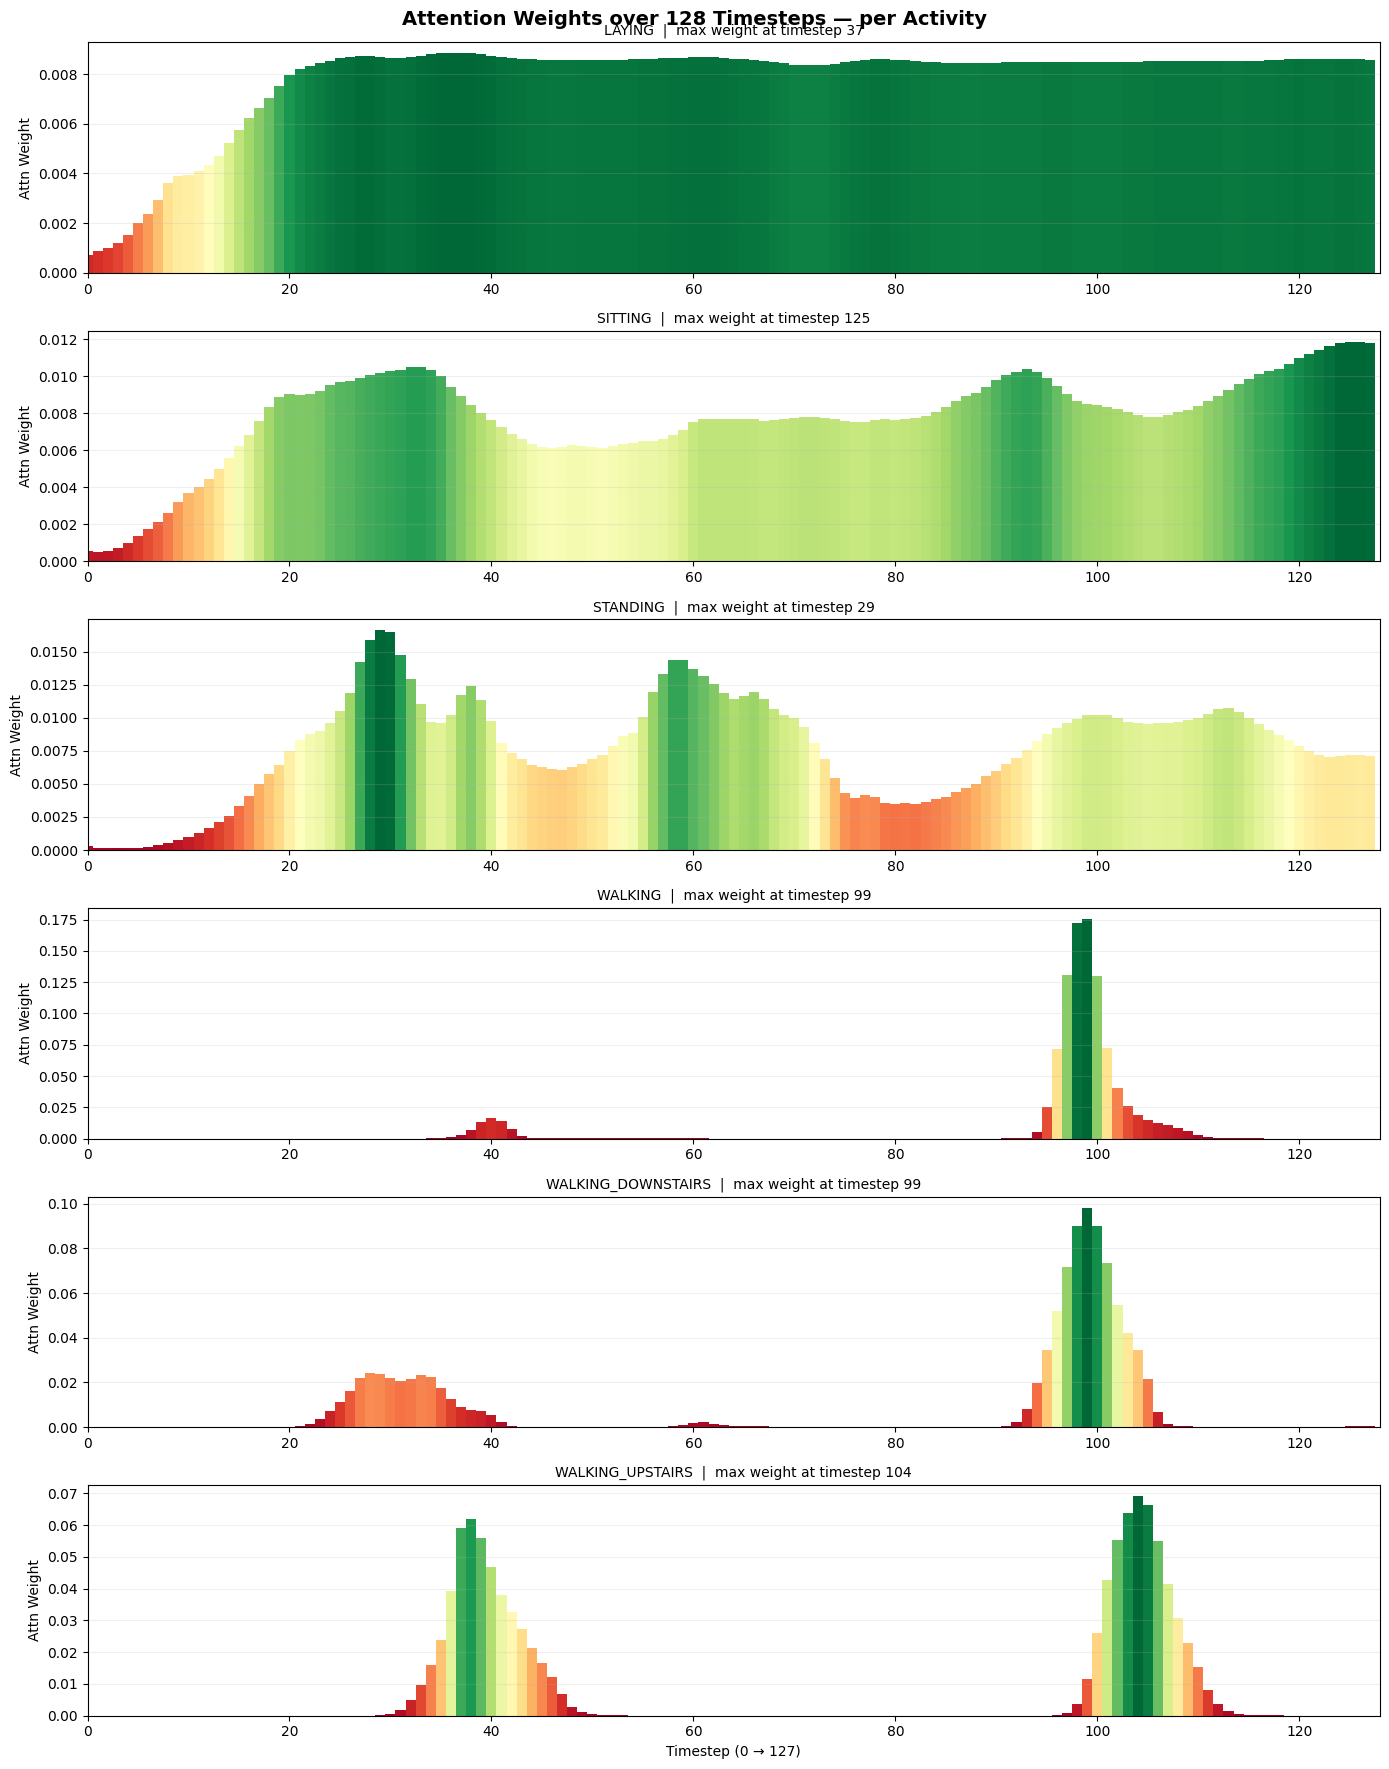

Saved: attention_heatmap_per_activity.png


In [60]:

activity_names = le_cnn.classes_          
n_activities   = len(activity_names)

fig, axes = plt.subplots(n_activities, 1, figsize=(14, 3 * n_activities))
fig.suptitle('Attention Weights over 128 Timesteps — per Activity',
             fontsize=14, fontweight='bold')

for idx, act in enumerate(activity_names):
    
    act_id   = le_cnn.transform([act])[0]
    pos      = np.where(y_test_cnn == act_id)[0][0]
    sample   = X_test_raw[pos:pos+1]                   

    _, w = attn_extractor.predict(sample, verbose=0)   
    weights = w[0, :, 0]                              

    
    axes[idx].bar(range(128), weights,
                  color=plt.cm.RdYlGn(weights / weights.max()),
                  width=1.0, edgecolor='none')
    axes[idx].set_title(f'{act}  |  max weight at timestep {weights.argmax()}',
                        fontsize=10)
    axes[idx].set_ylabel('Attn Weight')
    axes[idx].set_xlim(0, 128)
    axes[idx].grid(axis='y', alpha=0.2)

axes[-1].set_xlabel('Timestep (0 → 127)')
plt.tight_layout()
plt.savefig('attention_heatmap_per_activity.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: attention_heatmap_per_activity.png')

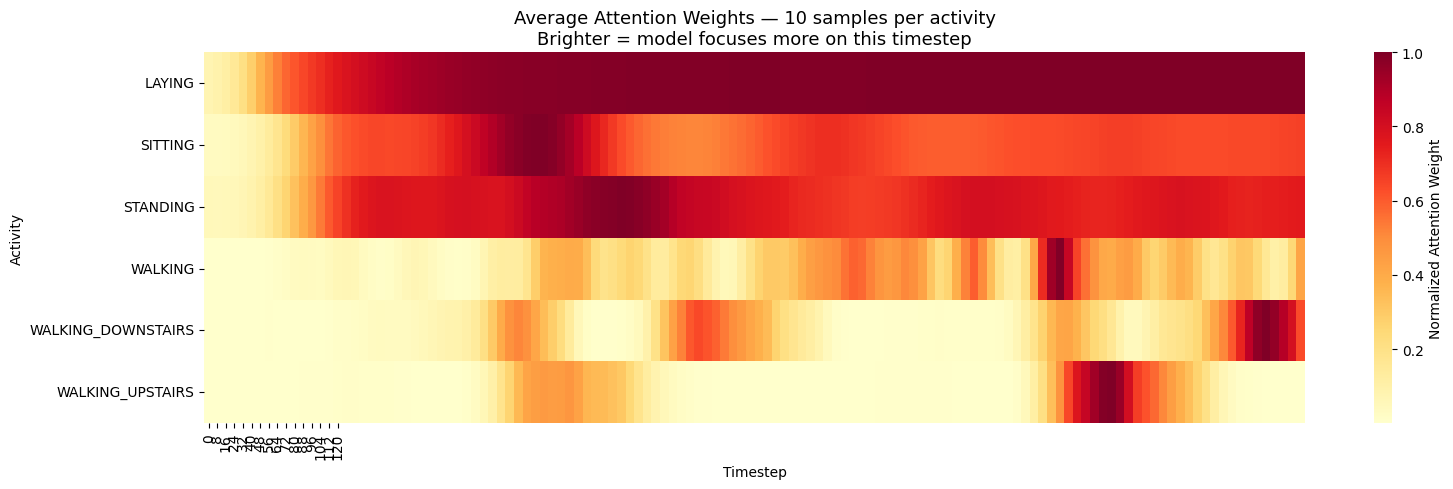

Saved: attention_2d_heatmap.png


In [61]:
SAMPLES_PER_ACT = 10
avg_weights     = np.zeros((n_activities, 128))

for idx, act in enumerate(activity_names):
    act_id   = le_cnn.transform([act])[0]
    positions = np.where(y_test_cnn == act_id)[0][:SAMPLES_PER_ACT]
    act_weights = []
    for pos in positions:
        sample = X_test_raw[pos:pos+1]
        _, w   = attn_extractor.predict(sample, verbose=0)
        act_weights.append(w[0, :, 0])
    avg_weights[idx] = np.mean(act_weights, axis=0)


avg_weights_norm = avg_weights / avg_weights.max(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(
    avg_weights_norm,
    ax=ax,
    cmap='YlOrRd',
    xticklabels=range(0, 128, 8),
    yticklabels=activity_names,
    cbar_kws={'label': 'Normalized Attention Weight'}
)
ax.set_title(f'Average Attention Weights — {SAMPLES_PER_ACT} samples per activity\n'
              'Brighter = model focuses more on this timestep', fontsize=13)
ax.set_xlabel('Timestep')
ax.set_ylabel('Activity')
plt.tight_layout()
plt.savefig('attention_2d_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: attention_2d_heatmap.png')

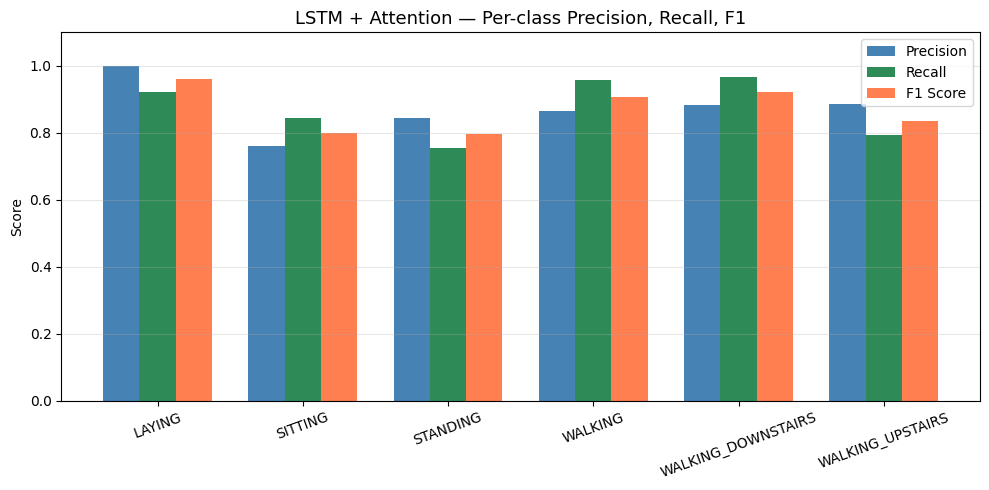


=== Full Classification Report ===
                    precision    recall  f1-score   support

            LAYING       1.00      0.92      0.96       537
           SITTING       0.76      0.84      0.80       491
          STANDING       0.84      0.76      0.80       532
           WALKING       0.86      0.96      0.91       496
WALKING_DOWNSTAIRS       0.88      0.97      0.92       420
  WALKING_UPSTAIRS       0.89      0.79      0.84       471

          accuracy                           0.87      2947
         macro avg       0.87      0.87      0.87      2947
      weighted avg       0.87      0.87      0.87      2947



In [62]:

from sklearn.metrics import classification_report

report = classification_report(
    y_test_cnn, y_pred_attn,
    target_names=le_cnn.classes_,
    output_dict=True
)
report_df = pd.DataFrame(report).T.iloc[:-3]   

fig, ax = plt.subplots(figsize=(10, 5))
x     = np.arange(len(le_cnn.classes_))
width = 0.25

ax.bar(x - width, report_df['precision'], width, label='Precision', color='steelblue')
ax.bar(x,         report_df['recall'],    width, label='Recall',    color='seagreen')
ax.bar(x + width, report_df['f1-score'],  width, label='F1 Score',  color='coral')

ax.set_xticks(x)
ax.set_xticklabels(le_cnn.classes_, rotation=20)
ax.set_ylim(0, 1.1)
ax.set_title('LSTM + Attention — Per-class Precision, Recall, F1', fontsize=13)
ax.set_ylabel('Score')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('attention_per_class_f1.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n=== Full Classification Report ===')
print(classification_report(y_test_cnn, y_pred_attn, target_names=le_cnn.classes_))